In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn

In [2]:
train_df = pd.read_csv("../music_rec/train.csv")
test_df = pd.read_csv("../music_rec/recommend - recommend.csv")

In [3]:
train_df.shape
train_df.head()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

Basic inspection of "train" dataset

In [4]:
train_df.isnull().sum().sort_values(ascending=False)

Unnamed: 0                  0
artist_name                 0
topic                       0
feelings                    0
sadness                     0
family/spiritual            0
light/visual perceptions    0
movement/places             0
music                       0
obscene                     0
communication               0
romantic                    0
family/gospel               0
shake the audience          0
night/time                  0
world/life                  0
violence                    0
dating                      0
len                         0
lyrics                      0
genre                       0
release_date                0
track_name                  0
age                         0
dtype: int64

Checking for missing values

In [5]:
identifier_cols = [
    'artist_name',
    'track_name'
]

Categorizing columns that are used for identifying song information, but is not useful for clustering in particular

In [6]:
text_cols = [
    'lyrics'
]

This column will be dropped later, due it being just raw text.

In [7]:
temporal_cols = [
    'release_date',
    'age'
]

'release_date' and 'age' are time-based variables based on a numeric ordering, so they're categorized in the temporal column so as to minimize their potential impact on clustering.

In [8]:
categorical_cols = [
    'genre',
    'topic'
]

'genre' and 'topic' do not prioritize any numeric ordering but instead discrete labels or classes, and would be thus considered categorical variables.

In [9]:
semantic_cols = [
    'dating',
    'violence',
    'world/life',
    'night/time',
    'shake the audience',
    'family/gospel',
    'romantic',
    'communication',
    'obscene',
    'music',
    'movement/places',
    'light/visual perceptions',
    'family/spiritual',
    'sadness',
    'feelings',
    'len'
]

These are all the semantic descriptors for the emotional and lyrical content, the semantic profile, of a hypothetically selected song. 'Len' also contains a degree of semantic implication that, while being expressed more mathematically, can be considered to contribute to thematic subject matter.

In [10]:
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,42948.166878,1990.239652,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,24747.811462,18.486997,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,0.000000,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,20393.500000,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,45407.000000,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,64089.500000,2007.000000,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,82451.000000,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


The means are notably higher than medians, suggesting most songs have low values while having large intensity in regards to content (should see heavy right skew)

In [11]:
df = train_df.copy()

Reassigning the train_df variable for convenience.

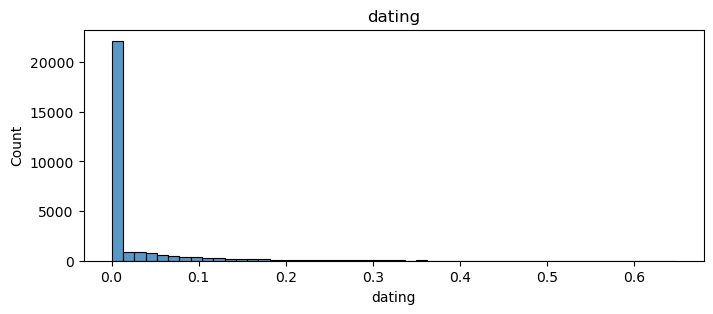

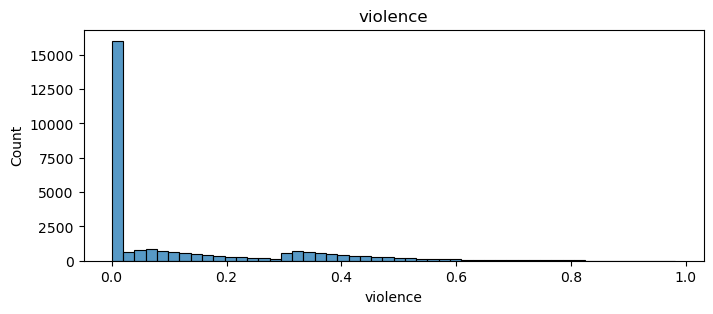

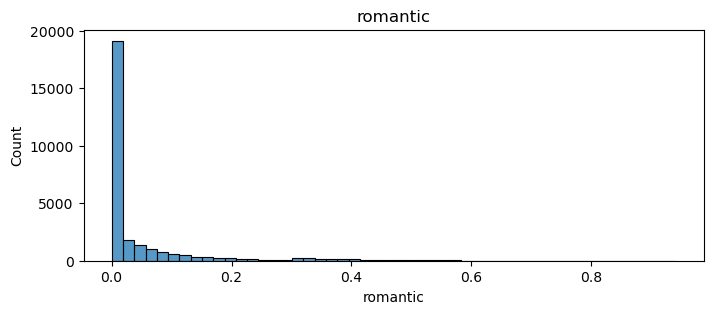

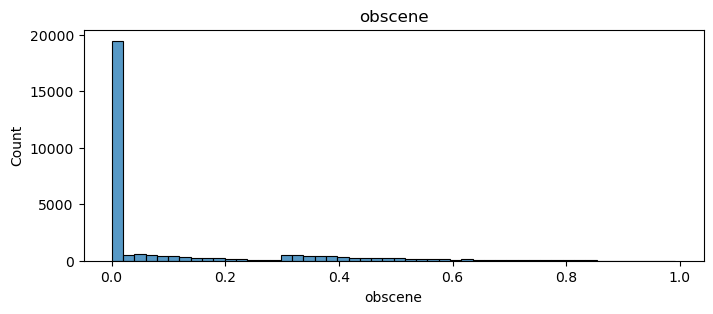

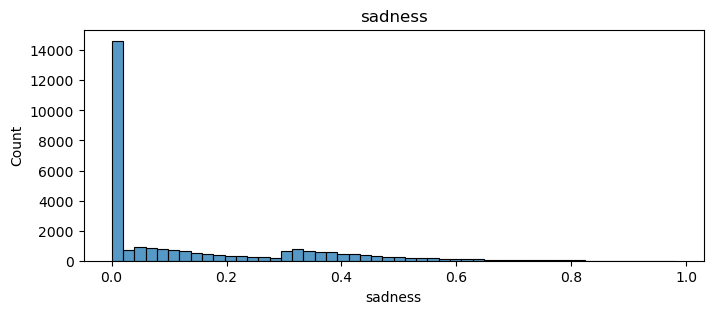

In [12]:
semantic_cols = [
    'dating',
    'violence',
    'romantic',
    'obscene',
    'sadness'
]

for col in semantic_cols:

    plt.figure(figsize=(8,3))

    sns.histplot(df[col], bins=50)

    plt.title(col)

    plt.show()

Songs consistently either have a large amount of thematic expression, or very little at all. Seemingly not necessarily bad for clustering, though.

In [13]:
df[['release_date', 'age']].corr()

,release_date,age
release_date,1.0,-1.0
age,-1.0,1.0


Correlation check - shows straightforward negative correlation. As release date increases, age decreases at the same rate, so this is feature redundancy right here. One of these two variables will need to be dropped in preprocessing. Release date info is more intuitive to keep when compared with age as "high" and "low" descriptors, personally.

array([[<Axes: title={'center': 'dating'}>,
        <Axes: title={'center': 'violence'}>],
       [<Axes: title={'center': 'romantic'}>,
        <Axes: title={'center': 'obscene'}>],
       [<Axes: title={'center': 'sadness'}>, <Axes: >]], dtype=object)

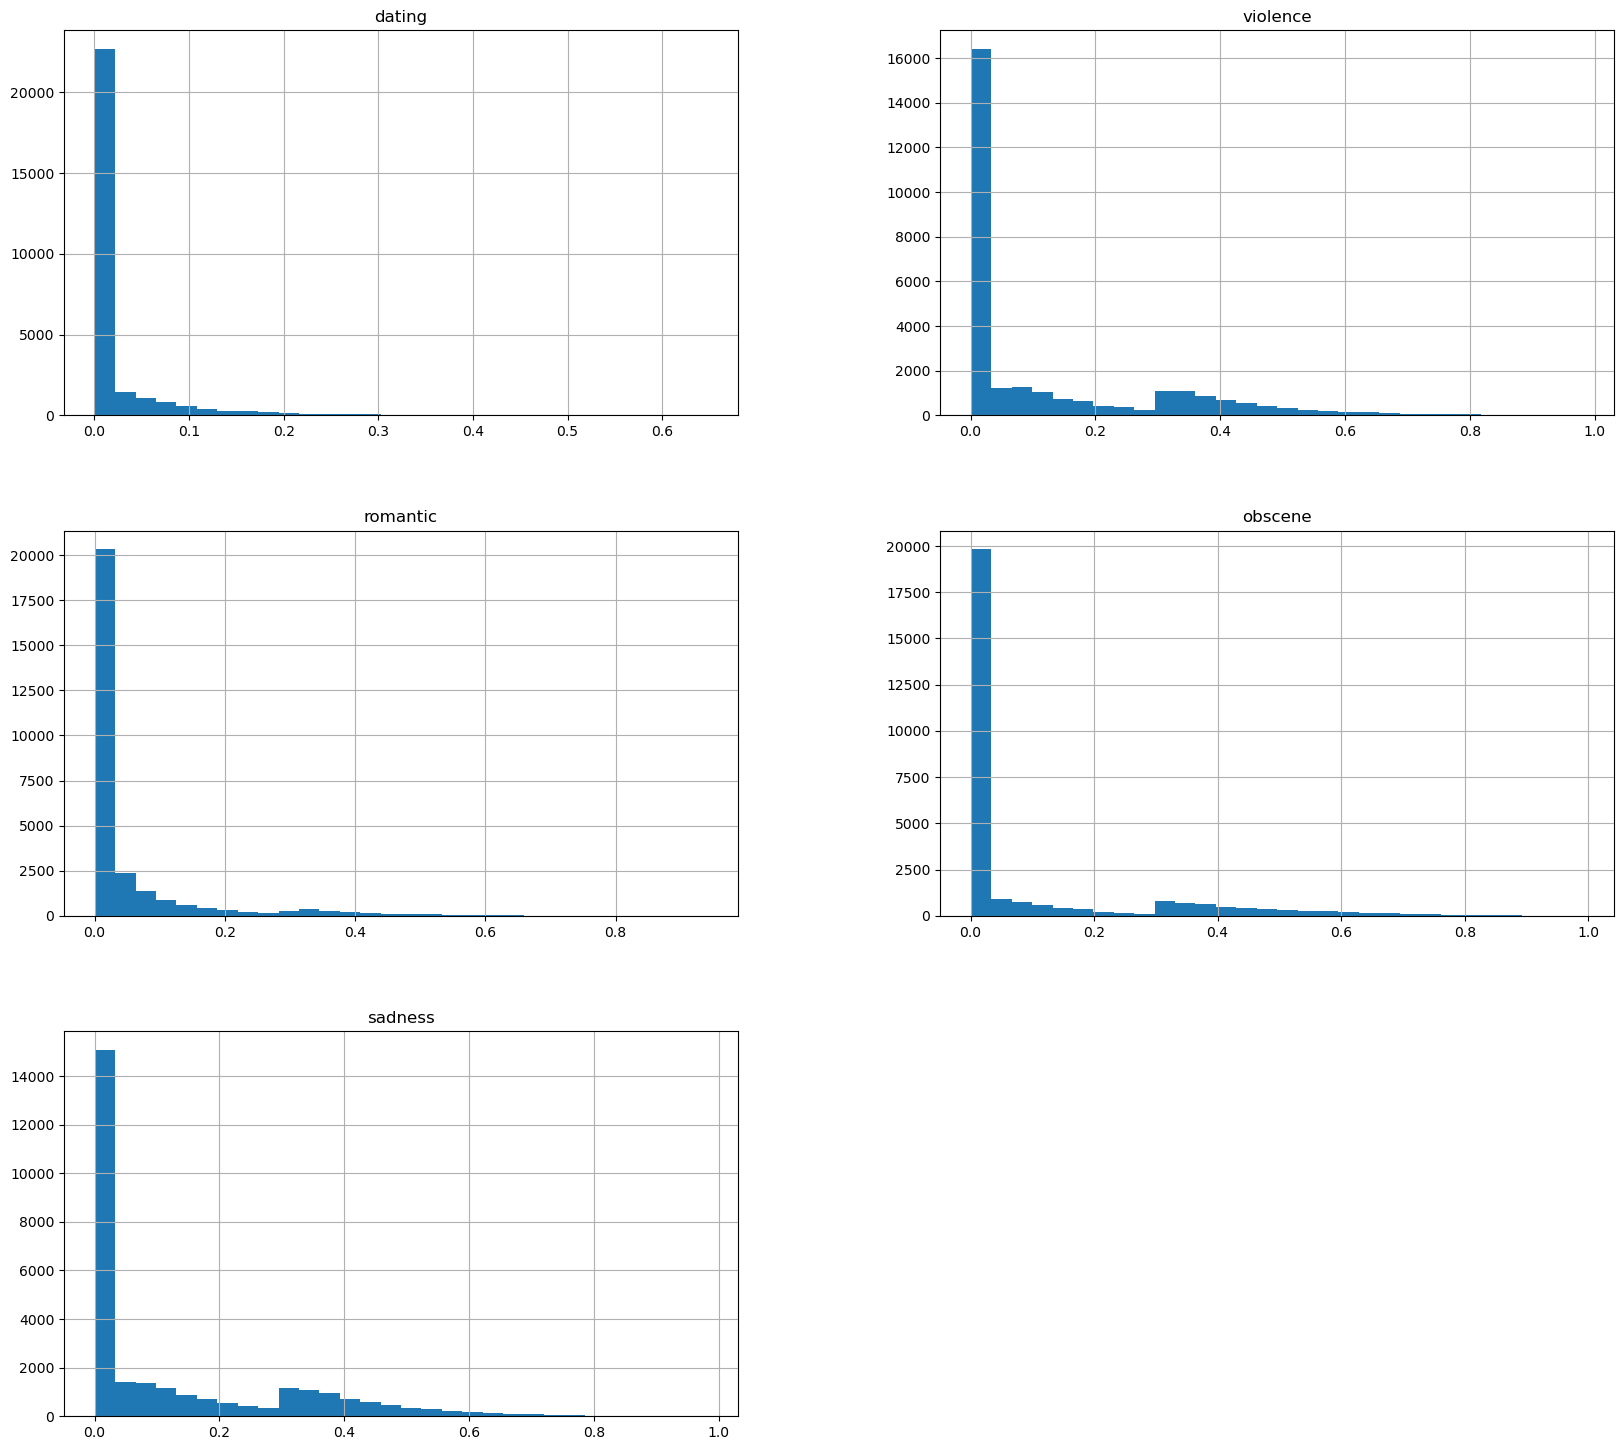

In [14]:
train_df[semantic_cols].hist(
    figsize=(20,18),
    bins=30
)

Looking at semantic features, many display substantial right-skewness, indicating that most songs weakly expressed a given lyrical theme while a smaller subset strongly embodied it. This suggests the dataset represents sparse semantic activation patterns rather than uniformly distributed continuous variables.

<Axes: >

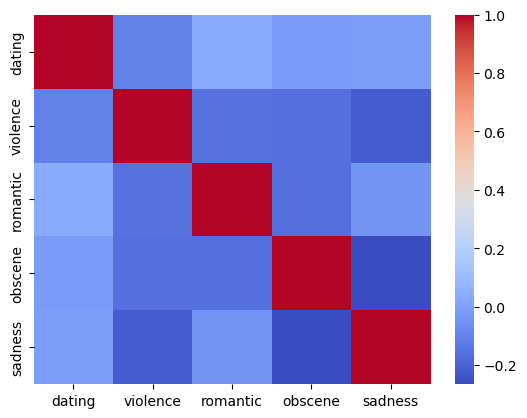

In [15]:
sns.heatmap(
    df[semantic_cols].corr(),
    cmap='coolwarm'
)

Correlation heatmap - negative correlations are visible with sadness and violence, as well as sadness and obscene content. Violent, obscene songs are perhaps likely to be bombastic and aggressive by nature, as opposed to introspective and downtempo. Getting visuals of this phenomenon will be useful.

<Axes: xlabel='sadness', ylabel='violence'>

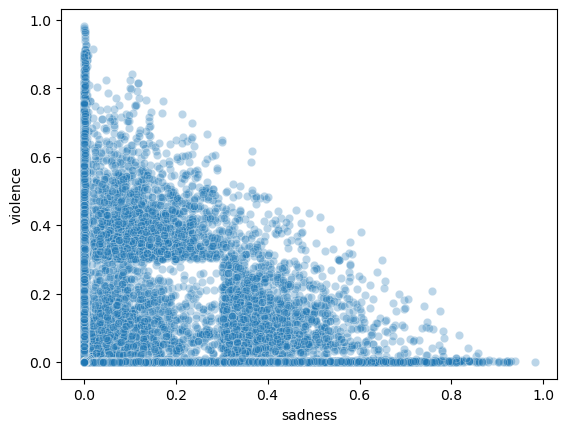

In [16]:
sns.scatterplot(
    x='sadness',
    y='violence',
    data=df,
    alpha=0.3
)

<Axes: xlabel='sadness', ylabel='obscene'>

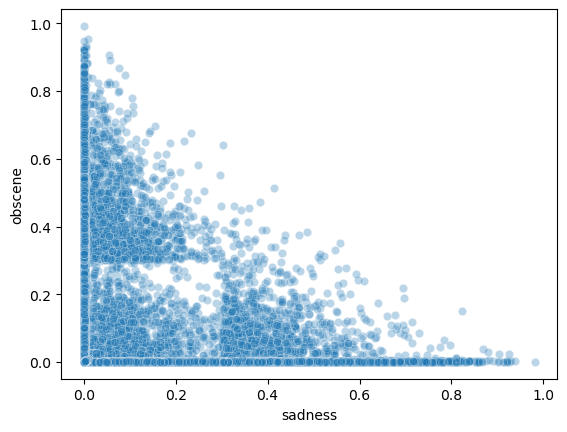

In [17]:
sns.scatterplot(
    x='sadness',
    y='obscene',
    data=df,
    alpha=0.3
)

Scatterplot analysis reveals semantically meaningful inverse relationships between "sadness" and "violent"/"obscene" lyrical themes. Songs with high sadness scores rarely exhibited simultaneously high violence or obscenity scores, suggesting latent emotional tradeoffs within lyrical content. Clustering is already poking through in the lower-left corner where there's a certain cutoff of sparseness; PCA is likely to be fruitful in digging deeper here.

<Axes: xlabel='dating', ylabel='romantic'>

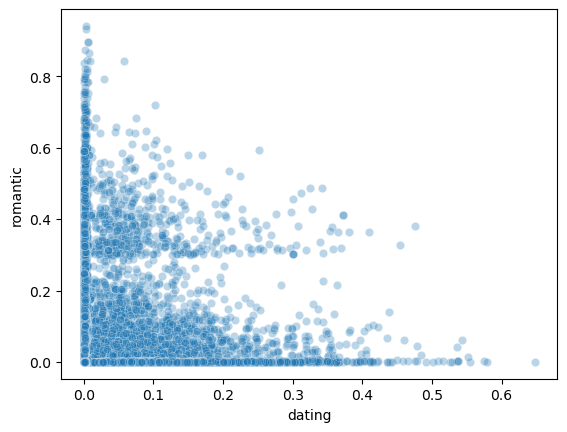

In [18]:
sns.scatterplot(
    x='dating',
    y='romantic',
    data=df,
    alpha=0.3
)

<Axes: xlabel='family/gospel', ylabel='family/spiritual'>

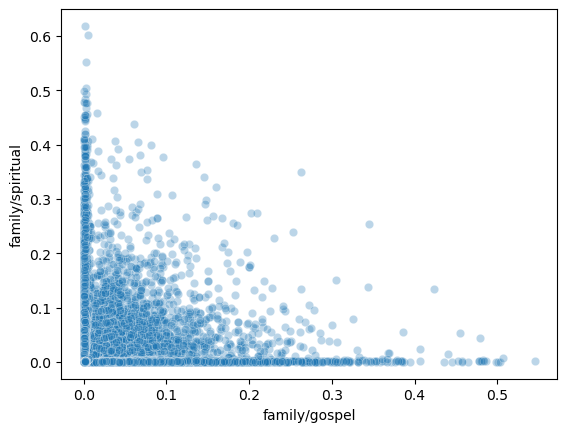

In [19]:
sns.scatterplot(
    x='family/gospel',
    y='family/spiritual',
    data=df,
    alpha=0.3
)

<Axes: xlabel='obscene', ylabel='shake the audience'>

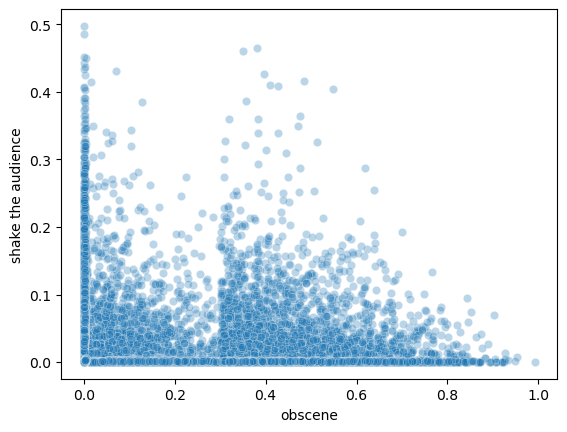

In [20]:
sns.scatterplot(
    x='obscene',
    y='shake the audience',
    data=df,
    alpha=0.3
)

Exploring some potential positive relationships (dating-romantic, family/gospel-family/spiritual, sadness/feelings, communication-romantic, obscene-shake the audience)



Dating and romantic themes demonstrate partial positive association, although the relationship was diffuse rather than strictly linear. Many songs exhibited romantic themes without strongly explicit dating content, suggesting that romantic expression represented a broader lyrical category.

The relationship between family/gospel and family/spiritual appeared diffuse rather than strongly linear. Although both variables represent related lyrical themes, the scatterplot demonstrates that songs with elevated spirituality scores did not always exhibit similarly high gospel-oriented content. This suggests that the dataset distinguishes between broader spiritual or family-centered emotional themes and explicitly gospel-oriented lyrical themes. Additionally, the strong concentration of observations near zero further reinforced the sparsity of semantic theme activation across the dataset.

The relation between obscene and shake the audience demonstrates partial thematic overlap without forming a tightly linear structure. Songs with elevated obscene lyrical content sometimes exhibit higher provocative or audience-oriented themes, although many songs with moderate obscenity scores maintain relatively low “shake the audience” activation. This suggests that explicit lyrical content and audience-provocation represent related but distinct semantic dimensions within the dataset.

Overall, the scatterplots collectively help to illustrate that songs likely occupy specialized thematic regions, and that clusters may form around strong thematic identities. The dataset does not appear to organize songs randomly, but rather by factors like emotional tone, thematic identity, lyrical intention, and semantic intensity. This all helps justify further PCA, clustering, and feature selection work.

In [21]:
semantic_cols = [
    'dating',
    'violence',
    'world/life',
    'night/time',
    'shake the audience',
    'family/gospel',
    'romantic',
    'communication',
    'obscene',
    'music',
    'movement/places',
    'light/visual perceptions',
    'family/spiritual',
    'sadness',
    'feelings',
    'len'
]

X = df[semantic_cols]

Creating a semantic feature matrix by isolating the semantic lyrical descriptiions, without including the more specific facets of the song data (titles, artists, etc.).

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

PCA needs to be scaled first for multivariate EDA.

In [23]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

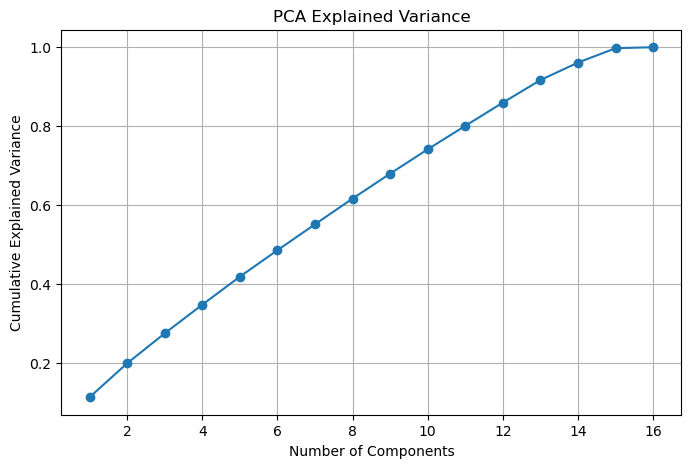

In [24]:
explained = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained)+1),
    explained,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

Explained variance plot that showcases the dataset's vast amounts of semantic diversity at play (lots of lyrical/theme directions), which is a good indicator for moving forward.

In [25]:
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

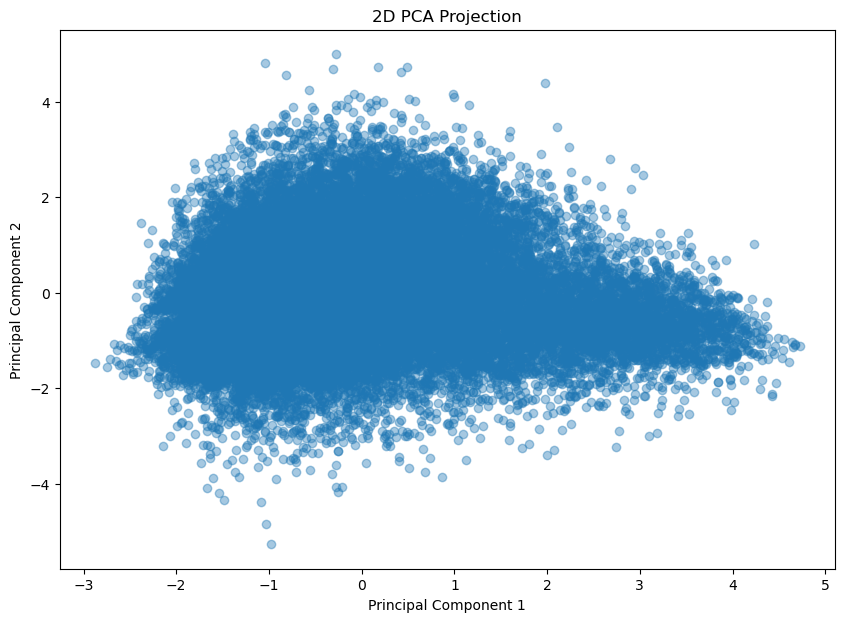

In [26]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("2D PCA Projection")

plt.show()

2D PCA Projection Plot - dots show how the 16 thematic measurements have been reduced to singular songs and their relative lyrical similarity expressed as a general summary direction. This is all to suggest that the song's contents are not randomly scattered about as a collective; many songs can be considered prevalent as you look toward the center mass along with rare ones on the outer edges. It's important to note that the thematic content of the music is governed by some sense of overarching similarityies or lack thereof, so as not to be discarded as random points when considering whether to do clustering.

Hypothesis: Clustering is expected to show that emotional and lyrical themes of a song is a predictor for the semantic grouping that it will be assigned with, which will make the cluster recommendations useful. Additionally, some songs having semantic opposition with each other, like introspective and aggressive tracks, will likely result in some amount of cluster separation.

Based on the exploratory analysis, several preprocessing considerations emerged. The dataset exhibited strong semantic sparsity, partial feature redundancy, and meaningful latent structure, suggesting that scaling and dimensionality reduction may improve clustering performance. Additionally, certain variables appeared highly correlated or conceptually overlapping, motivating further feature selection and preprocessing in the next stage of the project.